In [1]:
from VWCD import *

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def evaluate_vwcd_thresholds(
    input_dir,
    thresholds,
    vwcd_params,
    w=20,
    margin=3,
    value_col='value',
    cp_col='value_cp'
):
    results = []

    for thr in thresholds:
        TP = FP = TN = FN = 0

        for file in os.listdir(input_dir):
            if not file.endswith(".csv"):
                continue

            df = pd.read_csv(os.path.join(input_dir, file))

            if value_col not in df.columns or cp_col not in df.columns:
                continue

            # ===============================
            # Série COMPLETA
            # ===============================
            y = df[value_col].dropna().to_numpy()
            gt_flags = df.loc[df[value_col].notna(), cp_col].to_numpy().astype(int)

            # Executa VWCD na série completa
            params = vwcd_params.copy()
            params['X'] = y
            params['vote_p_thr'] = thr

            CP, _, _, _, _, _ = vwcd(**params)
            pred_cps_full = set(CP)

            # ===============================
            # Corte nas bordas (regime online)
            # ===============================
            gt_flags = gt_flags[w:-(w-1)]

            # CPs reais no domínio avaliado
            gt_cps = set(np.where(gt_flags == 1)[0])

            # CPs preditos realinhados ao domínio cortado
            pred_cps = {
                p - w
                for p in pred_cps_full
                if w <= p < len(y) - (w - 1)
            }

            # ===============================
            # Lógica EVENT-BASED com margem
            # ===============================
            matched_gt = set()
            matched_preds = set()
            tp = 0

            for gt in sorted(gt_cps):
                preds_in_margin = {
                    p for p in pred_cps
                    if abs(p - gt) <= margin and p not in matched_preds
                }
                if preds_in_margin:
                    tp += 1
                    matched_gt.add(gt)
                    matched_preds.update(preds_in_margin)

            fp = len(pred_cps - matched_preds)
            fn = len(gt_cps - matched_gt)

            # ===============================
            # TN coerente (domínio avaliado)
            # ===============================
            N_eval = len(gt_flags)
            tn = N_eval - tp - fp - fn

            TP += tp
            FP += fp
            FN += fn
            TN += tn

        # ===============================
        # Métricas
        # ===============================
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TPR
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        results.append({
            'threshold': thr,
            'TP': TP,
            'FP': FP,
            'TN': TN,
            'FN': FN,
            'TPR': TPR,
            'FPR': FPR,
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        })

    return pd.DataFrame(results)


def plot_roc_from_df(df, fpr_col='FPR', tpr_col='TPR', thr_col='threshold'):
    # Remove possíveis NaNs
    df_plot = df[[fpr_col, tpr_col, thr_col]].dropna()

    # Ordena por FPR (padrão ROC)
    df_plot = df_plot.sort_values(by=fpr_col)

    fpr = df_plot[fpr_col].to_numpy()
    tpr = df_plot[tpr_col].to_numpy()

    # AUC pelo método do trapézio
    auc = np.trapezoid(tpr, fpr)

    plt.figure()
    plt.plot(fpr, tpr, marker='o', label=f'ROC (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Aleatório')

    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Curva ROC – VWCD')
    plt.legend()
    plt.grid(True)

    plt.show()

def plot_pr_from_df(
    df,
    precision_col='Precision',
    recall_col='Recall',
    thr_col='threshold'
):

    df_plot = df[[precision_col, recall_col, thr_col]].copy()

    # Remove valores inválidos
    df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna()

    # Ordena por Recall (padrão PR)
    df_plot = df_plot.sort_values(by=recall_col)

    recall = df_plot[recall_col].to_numpy()
    precision = df_plot[precision_col].to_numpy()

    # Área sob a curva PR
    auprc = np.trapezoid(precision, recall)

    plt.figure()
    plt.plot(
        recall,
        precision,
        marker='o',
        label=f'PR (AUPRC = {auprc:.3f})'
    )

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision–Recall  – VWCD')
    plt.grid(True)
    plt.legend()
    plt.show()


    threshold   TP     FP     TN   FN   TPR       FPR  Precision  Recall  \
0         0.0  100  26000      0    0  1.00  1.000000   0.003831    1.00   
1         0.1   94   2622  23378    6  0.94  0.100846   0.034610    0.94   
2         0.2   89    428  25572   11  0.89  0.016462   0.172147    0.89   
3         0.3   84     98  25902   16  0.84  0.003769   0.461538    0.84   
4         0.4   71     31  25969   29  0.71  0.001192   0.696078    0.71   
5         0.5   65      8  25992   35  0.65  0.000308   0.890411    0.65   
6         0.6   54      1  25999   46  0.54  0.000038   0.981818    0.54   
7         0.7   41      1  25999   59  0.41  0.000038   0.976190    0.41   
8         0.8   22      1  25999   78  0.22  0.000038   0.956522    0.22   
9         0.9    2      1  25999   98  0.02  0.000038   0.666667    0.02   
10        1.0    0      0  26000  100  0.00  0.000000   0.000000    0.00   

          F1  
0   0.007634  
1   0.066761  
2   0.288493  
3   0.595745  
4   0.702970

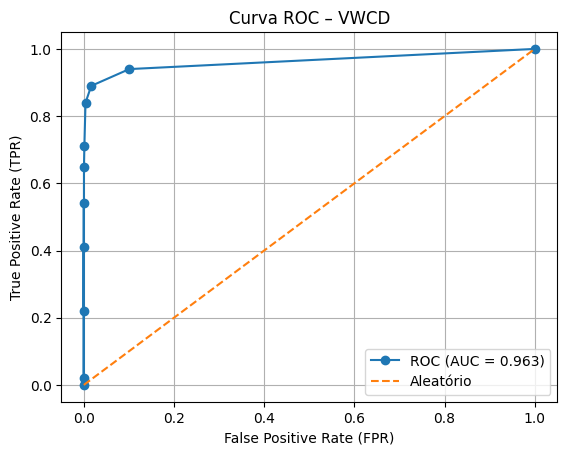

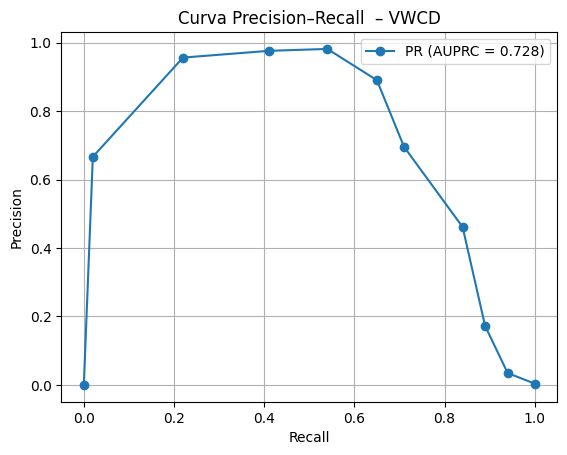

In [2]:
thresholds = np.linspace(0, 1, 11)
vwcd_params = {
    'w': 20,
    'ab': 30,
    'aggreg': agg_linear,
    'pesos': ws_U,
    'lamb': 1,
    'lamb_w': 1,
    'verbose': False
}
df_metrics = evaluate_vwcd_thresholds(
    input_dir='time_series/teste_m130',
    thresholds=thresholds,
    vwcd_params=vwcd_params,
    margin=0
)
print(df_metrics)
plot_roc_from_df(df_metrics)
plot_pr_from_df(df_metrics)